# 分类器扩散引导 (Classifier Diffusion Guidance)

在扩散引导（Guided Diffusion）中，我们可以通过引导生成过程来提升采样结果的**质量**（`quality`）与**多样性**（`diversity`）。  
在本教程中将首先介绍**分类器扩散引导**（`Classifier Diffusion Guidance`）。

在[前一个示例](./05-class-conditional-cn.ipynb)中，我们假设在扩散模型训练阶段已知类别标签，并将类别标签作为输入喂给扩散模型。  
而在使用**分类器引导**时，我们从一个已经训练好的扩散模型（通常是**无条件扩散模型**(`unconditional diffusion model`)）出发，在**推理阶段**对生成过程进行引导。

使用分类器引导具有以下特点：

- 即使与传统的条件扩散模型结合使用，也可以显著提升图像生成的**保真度（fidelity）**（见[前一个示例](./05-class-conditional-cn.ipynb)）。
- 可以在**生成质量与多样性之间进行可控权衡**，类似于大语言模型中的 $temperature$ 参数（参见后文结构中的**梯度缩放参数**）。
- 即使对于**无条件扩散模型**，同样可以应用引导机制。

在本教程中，我们假设引导信息是**类别标签**，因此需要额外构建一个**图像分类器**。  
不过，该方法同样可以扩展到基于**文本提示**（`text prompt`）的条件模型中（见下方说明）。

## 架构与方法 (Architecture & Method)

让我们简要地跟随原始论文 [[Dhariwal & Nichol, 2021](https://arxiv.org/pdf/2105.05233)] 的理论方面来了解分类器引导。

### 1. 条件采样公式：$p(\mathbf{x}_t \mid \mathbf{x}_{t+1}, y)$

现在我们假设最优的 $p(\mathbf{x}_t \mid \mathbf{x}_{t+1}, y)$（即以类别标签 $y$ 为条件的分布）是已知的，并考察该最优分布的性质。

首先假设每个样本 $\mathbf{x}_0$ 都具有已知的标签，而 $\mathbf{x}_1, \ldots, \mathbf{x}_T$ 是加噪后的图像，这与 [DDPM 教程](./02-ddpm-cn.ipynb) 中的设定一致。  
如同在 [DDPM 教程](./02-ddpm-cn.ipynb) 中所示，我们可以假设 
$
p(\mathbf{x}_{t+1} \mid \mathbf{x}_t, y) = q(\mathbf{x}_{t+1} \mid \mathbf{x}_t)
$
，即该分布不依赖于 $y$，其中 $q(\mathbf{x}_{t+1} \mid \mathbf{x}_t)$ 是 [DDPM 教程](./02-ddpm-cn.ipynb) 中给出的前向扩散概率（参见该文中的公式 (1)）。

在此假设下，有：

$
p(\mathbf{x}_{t+1} \mid \mathbf{x}_t)
$

$
= \sum_y p(\mathbf{x}_{t+1}, y \mid \mathbf{x}_t)
$

$
= \sum_y p(\mathbf{x}_{t+1} \mid \mathbf{x}_t, y) \, p(y \mid \mathbf{x}_t)
$

$
= \sum_y q(\mathbf{x}_{t+1} \mid \mathbf{x}_t) \, p(y \mid \mathbf{x}_t)
$

$
= q(\mathbf{x}_{t+1} \mid \mathbf{x}_t) \sum_y p(y \mid \mathbf{x}_t)
$

$
= q(\mathbf{x}_{t+1} \mid \mathbf{x}_t)
$

$
= p(\mathbf{x}_{t+1} \mid \mathbf{x}_t, y)
$

> 注：这里使用了  
> $p(\mathbf{x}_{t+1}, y \mid \mathbf{x}_t) = p(\mathbf{x}_{t+1} \mid \mathbf{x}_t, y) p(y \mid \mathbf{x}_t)$，  
> 因为  
> $p(\mathbf{x}_{t+1}, y \mid \mathbf{x}_t) p(\mathbf{x}_t) = p(\mathbf{x}_{t+1} \mid \mathbf{x}_t, y) p(y \mid \mathbf{x}_t) p(\mathbf{x}_t)$。

同时有：

$
p(y \mid \mathbf{x}_t, \mathbf{x}_{t+1})
$

$
= p(\mathbf{x}_{t+1} \mid \mathbf{x}_t, y) \frac{p(y \mid \mathbf{x}_t)}{p(\mathbf{x}_{t+1} \mid \mathbf{x}_t)}
$

$
= p(\mathbf{x}_{t+1} \mid \mathbf{x}_t) \frac{p(y \mid \mathbf{x}_t)}{p(\mathbf{x}_{t+1} \mid \mathbf{x}_t)}
$

$
= p(y \mid \mathbf{x}_t) \qquad (1)
$

> 注：这里还使用了  
> $p(y \mid \mathbf{x}_t, \mathbf{x}_{t+1}) p(\mathbf{x}_{t+1} \mid \mathbf{x}_t) = p(\mathbf{x}_{t+1} \mid \mathbf{x}_t, y) p(y \mid \mathbf{x}_t)$，  
> 因为  
> $p(y \mid \mathbf{x}_t, \mathbf{x}_{t+1}) p(\mathbf{x}_{t+1} \mid \mathbf{x}_t) p(\mathbf{x}_t) = p(\mathbf{x}_{t+1} \mid \mathbf{x}_t, y) p(y \mid \mathbf{x}_t) p(\mathbf{x}_t)$。

根据贝叶斯公式并结合式 (1)，可得：

$
p(\mathbf{x}_t \mid \mathbf{x}_{t+1}, y)
$

$
= \frac{p(\mathbf{x}_t, \mathbf{x}_{t+1}, y)}{p(\mathbf{x}_{t+1}, y)}
$

$
= \frac{p(\mathbf{x}_t \mid \mathbf{x}_{t+1}) \, p(y \mid \mathbf{x}_t, \mathbf{x}_{t+1}) \, p(\mathbf{x}_{t+1})}{p(y \mid \mathbf{x}_{t+1}) \, p(\mathbf{x}_{t+1})}
$

$
= \frac{p(\mathbf{x}_t \mid \mathbf{x}_{t+1}) \, p(y \mid \mathbf{x}_t, \mathbf{x}_{t+1})}{p(y \mid \mathbf{x}_{t+1})}
$

$
= \frac{p(\mathbf{x}_t \mid \mathbf{x}_{t+1}) \, p(y \mid \mathbf{x}_t)}{p(y \mid \mathbf{x}_{t+1})}
$

由于 $\frac{1}{p(y \mid \mathbf{x}_{t+1})}$ 不依赖于 $\mathbf{x}_t$，因此当给定 $\mathbf{x}_{t+1}$ 和 $y$ 时，反向采样分布 $p(\mathbf{x}_t \mid \mathbf{x}_{t+1}, y)$ 可写为：

$
p(\mathbf{x}_t \mid \mathbf{x}_{t+1}, y) = Z \, p_{\theta}(\mathbf{x}_t \mid \mathbf{x}_{t+1}) \, p_{\phi}(y \mid \mathbf{x}_t) \qquad (2)
$

其中 $Z$ 为归一化常数，$\theta$ 表示去噪模型的参数，$\phi$ 表示分类器模型的参数。

> 注：截至此处的证明可参见原论文附录 H: [[Dhariwal & Nichol, 2021](https://arxiv.org/pdf/2105.05233)].

值得注意的是，在实际实现中，分类器 $p_{\phi}(y \mid \mathbf{x}_t)$ 实际上为
$
p_{\phi}(y \mid \mathbf{x}_t, t)
$
因为分类器需要利用不同噪声步 $t=0,\ldots,T$ 下的带噪图像 $\mathbf{x}_t$ 来预测标签 $y$。

---

### 2. 分析 $p_{\theta}(\mathbf{x}_t \mid \mathbf{x}_{t+1}) \, p_{\phi}(y \mid \mathbf{x}_t)$

现在我们分析公式 (2) 右侧（RHS）的具体形式。

与 [DDPM 教程](./02-ddpm-cn.ipynb) 相同，我们假设 $p(\mathbf{x}_t \mid \mathbf{x}_{t+1}, y)$ 同样服从高斯分布，即：

$
p(\mathbf{x}_t \mid \mathbf{x}_{t+1}) = \mathcal{N}(\mu, \Sigma)
$

其对数概率可以写为：

$
\log p(\mathbf{x}_t \mid \mathbf{x}_{t+1}) 
= -\frac{1}{2} (\mathbf{x}_t - \mu)^T \Sigma^{-1} (\mathbf{x}_t - \mu) + C_1 \qquad (3)
$

其中 $C_1$ 为常数，$T$ 表示矩阵转置（transpose）

接下来，对分类对数概率 $\log p(y \mid \mathbf{x}_t)$ 在 $\mathbf{x}_t = \mu$ 处进行一阶线性近似，可得：

$
\log p(y \mid \mathbf{x}_t)
$

$
\approx \log p(y \mid \mathbf{x}_t)\big|_{\mathbf{x}_t=\mu} 
+ (\mathbf{x}_t - \mu) \, \nabla_{\mathbf{x}_t} \log p(y \mid \mathbf{x}_t)\big|_{\mathbf{x}_t=\mu}
$

$
= (\mathbf{x}_t - \mu) \, g + C_2 \qquad (4)
$

其中

$
g = \nabla_{\mathbf{x}_t} \log p(y \mid \mathbf{x}_t)\big|_{\mathbf{x}_t=\mu}
$

且 $C_2$ 为常数。

结合公式 (3) 与 (4)，可得：

$
\log \big( p_{\theta}(\mathbf{x}_t \mid \mathbf{x}_{t+1}) \, p_{\phi}(y \mid \mathbf{x}_t) \big)
$

$
\approx -\frac{1}{2} (\mathbf{x}_t - \mu)^T \Sigma^{-1} (\mathbf{x}_t - \mu) 
+ (\mathbf{x}_t - \mu) \, g + C_3
$

$
= -\frac{1}{2} (\mathbf{x}_t - \mu - \Sigma g)^T \Sigma^{-1} (\mathbf{x}_t - \mu - \Sigma g)
+ \frac{1}{2} g^T \Sigma g + C_3
$

$
= -\frac{1}{2} (\mathbf{x}_t - \mu - \Sigma g)^T \Sigma^{-1} (\mathbf{x}_t - \mu - \Sigma g) + C_4
$

$
= \log p(\mathbf{z}) + C_5, 
\quad \text{其中 } \mathbf{z} \sim \mathcal{N}(\mu + \Sigma g, \Sigma) \qquad (5)
$

---

### 3. 分类器引导算法

由上述推导可知，当扩散模型 $\mathcal{N}(\mu_{\theta}(\mathbf{x}_t), \sigma_t^2 \mathbf{I})$ 和分类器 $p_{\phi}(y \mid \mathbf{x}_t)$ 均已给定时，其采样算法如下：

1. 采样初始白噪声

   $
   \mathbf{x}_T \sim \mathcal{N}(\mathbf{0}, \mathbf{I})
   $

3. 对 $t = T, \ldots, 1$，循环执行以下步骤：
   - 设

     $
     \mu, \Sigma \leftarrow \mu_{\theta}(\mathbf{x}_t), \; \sigma_t^2 \mathbf{I}
     $

   - 采样

     $
     \mathbf{x}_{t-1} \sim \mathcal{N}\big(\mu + s \Sigma \nabla_{\mathbf{x}_t} \log p_{\phi}(y \mid \mathbf{x}_t), \; \Sigma \big)
     $

     其中 $s$ 为梯度缩放系数（固定超参数）。
  
     
4. 返回 $\mathbf{x}_0$

> 注：此处假设所使用的扩散模型与 [DDPM 教程](./02-ddpm-cn.ipynb) 中相同（其中 $\Sigma$ 不可学习）。  
> 当 $\Sigma$ 为可学习参数时，应设
$
 \Sigma \leftarrow \Sigma_{\theta}(\mathbf{x}_t)
$
> 

该结果从直观上表明：**为了使生成样本符合给定类别，只需在反向扩散过程中调整均值，使样本朝着提高该类别概率的方向移动**。

如 [DDPM 教程](./02-ddpm-cn.ipynb) 所示，通过重参数化可得：

$
\mu_{\theta}(\mathbf{x}_t) = \frac{1}{\sqrt{\alpha_t}} \left( \mathbf{x}_t - \frac{1 - \alpha_t}{\sqrt{1 - \overline{\alpha}_t}} \, \epsilon_{\theta}(\mathbf{x}_t) \right)
$

$
\sigma_t^2 = \frac{(1 - \alpha_t)(1 - \overline{\alpha}_{t-1})}{1 - \overline{\alpha}_t}
$

---

### 4. 【可选】在噪声预测 $\epsilon_{\theta}(\mathbf{x}_t)$ 中的分类器引导

正如我们在 SDE 视角下的**祖先采样**（`ancestral sampling`）中所看到的那样，DDPM 可以通过 **score matching** 进行解释（参见 [SDE 教程](./04-sde-cn.ipynb) 中的公式 (9)）。祖先采样是一种基于原始 DDPM 算法的采样方法。

$
\mathbf{x}_{t-1}
= \frac{1}{\sqrt{1-\beta_t}}
\left(
\mathbf{x}_t + \beta_t \nabla_{\mathbf{x}_t} \log p(\mathbf{x}_t)
\right)
+ \sqrt{\beta_t} \mathbf{z}_t
$

> 注：在 score matching 中，$\nabla_{\mathbf{x}_t} \log p(\mathbf{x}_t)$ 被替换为 $\mathbf{s}_{\theta^{\ast}}(\mathbf{x}_t, t)$。

由于

$
\mu_{\theta}(\mathbf{x}_t)
= \frac{1}{\sqrt{\alpha_t}}
\left(
\mathbf{x}_t - \frac{1-\alpha_t}{\sqrt{1-\overline{\alpha}_t}} \epsilon_{\theta}(\mathbf{x}_t)
\right),
$

这意味着

$
\frac{1}{\sqrt{1-\beta_t}} \beta_t \nabla_{\mathbf{x}_t} \log p(\mathbf{x}_t)
= -\frac{1}{\sqrt{\alpha_t}} \frac{1-\alpha_t}{\sqrt{1-\overline{\alpha}_t}} \epsilon_{\theta}(\mathbf{x}_t),
$

并由此得到噪声预测与 score 之间的关系：

$
\epsilon_{\theta}(\mathbf{x}_t)
= -\sqrt{1 - \overline{\alpha}_t} \nabla_{\mathbf{x}_t} \log p(\mathbf{x}_t)
$

> 注：众所周知，当噪声预测模型 $\epsilon_{\theta}(\mathbf{x}_t)$ 训练良好时，它预测的是缩放后的 score：
$
 \epsilon_{\theta}(\mathbf{x}_t) \approx -\sigma_t \nabla_{\mathbf{x}_t} \log p(\mathbf{x}_t)
$
> 

将其代入条件 score $\nabla_{\mathbf{x}_t} \log p(\mathbf{x}_t, y)$，得到：

$
\nabla_{\mathbf{x}_t} \log p(\mathbf{x}_t, y)
= \nabla_{\mathbf{x}_t} \log \big( p_{\theta}(\mathbf{x}_t) p_{\phi}(y \mid \mathbf{x}_t) \big)
$

$
= \nabla_{\mathbf{x}_t} \log p_{\theta}(\mathbf{x}_t)
+ \nabla_{\mathbf{x}_t} \log p_{\phi}(y \mid \mathbf{x}_t)
$

$
= -\frac{1}{\sqrt{1 - \overline{\alpha}_t}} \epsilon_{\theta}(\mathbf{x}_t)
+ \nabla_{\mathbf{x}_t} \log p_{\phi}(y \mid \mathbf{x}_t)
$

因此，新的
$
\tilde{\epsilon}_{\theta}(\mathbf{x}_t)
\; \big( = -\sqrt{1 - \overline{\alpha}_t} \nabla_{\mathbf{x}_t} \log p(\mathbf{x}_t, y) \big)
$
可表示为：

$
\tilde{\epsilon}_{\theta}(\mathbf{x}_t)
= \epsilon_{\theta}(\mathbf{x}_t)
- \sqrt{1 - \overline{\alpha}_t} \nabla_{\mathbf{x}_t} \log p_{\phi}(y \mid \mathbf{x}_t)
$

进一步引入梯度缩放系数 $s$，得到最终形式：

$
\tilde{\epsilon}_{\theta}(\mathbf{x}_t)
= \epsilon_{\theta}(\mathbf{x}_t)
- s \sqrt{1 - \overline{\alpha}_t} \nabla_{\mathbf{x}_t} \log p_{\phi}(y \mid \mathbf{x}_t)
\qquad (6)
$

本文不再展开，但该结果可以应用于 [DDIM](https://arxiv.org/pdf/2010.02502) 中，从而显著加速采样过程（即图像生成速度）。


---

### 5. 【可选】实践应用中的说明

在理论上，将梯度缩放系数设为 $s+1$ 并应用于**无条件扩散模型**的分类器引导，与将梯度缩放系数设为 $s$ 并应用于**条件扩散模型**的分类器引导是等价的，因为：

$
\epsilon_{\theta}(\mathbf{x}_t) - (s+1)\sigma_t \nabla_{\mathbf{x}_t} \log p_{\phi}(y \mid \mathbf{x}_t)
$

$
\approx - \sigma_t \nabla_{\mathbf{x}_t} \big[ \log p(\mathbf{x}_t) + (s+1)\log p_{\phi}(y \mid \mathbf{x}_t) \big]
$

$
= - \sigma_t \nabla_{\mathbf{x}_t} \big[ \log p(\mathbf{x}_t, y) + s \log p_{\phi}(y \mid \mathbf{x}_t) \big]
$

> 注：参见 [[Ho & Salimans, 2022](https://arxiv.org/pdf/2207.12598)]论文第 3.1 节。

然而，[[Nichol & Dhariwal, 2021](https://arxiv.org/pdf/2102.09672)] 指出，相比在无条件扩散模型上应用分类器引导，将分类器引导应用在**已经是类别条件化的扩散模型**上可以获得更优的性能。

在本教程中，为了教学目的，我们将在一个已经训练好的**无条件扩散模型**（该模型在 [DDPM 教程](./02-ddpm-cn.ipynb) 中训练完成）上应用分类器引导；但在实际应用中，更推荐将分类器引导应用到**已是类别条件化的扩散模型**上，并将梯度缩放系数 $s$ 设为较小的值，以获得更好的生成效果。

这一事实也引出了后续教程中讨论的**无分类器引导**（`classifier-free guidance`）方法（见 [下一节教程](./07-classifier-free-guidance-cn.ipynb)）。

## 注：基于文本提示的分类器引导（Text-to-Image）

在本示例中，我们为了教学目的，构建了一个基于类别标签的简单分类器引导模型。  
但你也可以将该架构推广到**基于通用文本提示（text prompt）条件化的引导模型**中，例如通过引入文本编码器（如 [Transformer 编码器](https://github.com/tsmatz/nlp-tutorials/blob/master/09_transformer.ipynb) 等）。

例如，GLIDE 中的 **CLIP 引导**使用 CLIP 模型对文本序列进行编码（参见 [GLIDE 论文](https://arxiv.org/pdf/2112.10741)）。  
CLIP 由两个模型组成 —— 图像编码器 $f(\mathbf{x})$ 与文本（描述）编码器 $g(c)$ —— 图像 $\mathbf{x}$ 与文本提示 $c$ 之间的相似度通过点积计算：
$$
f(\mathbf{x}) \cdot g(c)
$$

在应用分类器引导方法后，条件反向过程
$$
\mathcal{N}\big(\mu_{\theta}(\mathbf{x}_t \mid c), \Sigma_{\theta}(\mathbf{x}_t \mid c)\big)
$$
中的均值将按照下式通过梯度进行扰动：
$$
\tilde{\mu}_{\theta}(\mathbf{x}_t \mid c)
= \mu_{\theta}(\mathbf{x}_t \mid c)
+ s \cdot \Sigma_{\theta}(\mathbf{x}_t \mid c) \nabla_{\mathbf{x}_t}\big( f(\mathbf{x}) \cdot g(c) \big)
$$

> 注：论文中更倾向于使用**带噪图像**来进行 score 的训练；但在实际应用中，未在带噪图像上训练的**公开 CLIP 模型**同样可以有效地用于引导扩散模型。

---

## 实现 (Implementation)

现在我们将结合理论解释，逐步查看对应的代码实现过程。

> 注：官方实现请参见(这里)[https://github.com/openai/guided-diffusion]
> 在该项目中，你可以直接使用在 ImageNet 数据集（包含 1000 个类别）上训练好的扩散模型与分类器进行实验。


在我们开始之前，我们需要安装所需的包。

In [8]:
!pip install torch torchvision numpy matplotlib tqdm

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


### 1. 构建加噪图像分类器：$p_{\phi}(y | \mathbf{x}_t, t)$ 

首先我们使用 **CIFAR-10** 数据集构建一个分类器 $p_{\phi}(y | \mathbf{x}_t, t)$。

在构建分类器之前，我们加载 CIFAR-10 数据集及其数据加载器。
每个批次具有形状 ```[batch_size, 3, 32 32]```。

In [10]:
import torch
from torchvision import datasets, transforms

batch_size = 256

dataset = datasets.CIFAR10(
    "./data",
    train=True,
    download=True,
    transform=transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
    ]))
loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

Files already downloaded and verified


现在我展示 100 个例子。

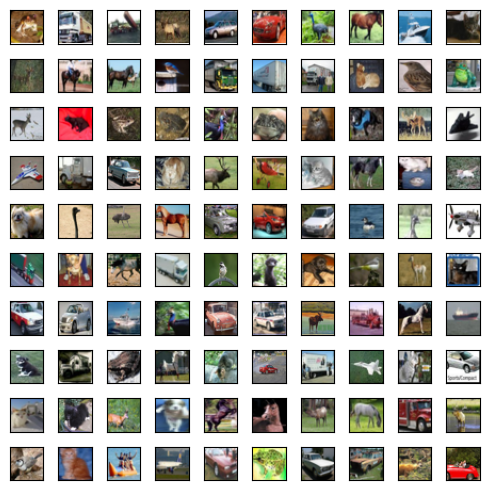

In [12]:
import numpy as np
import matplotlib.pyplot as plt

"""
for _, (data, _) in enumerate(loader):
    images = data[:3]
    break
for i in images:
    channel_last = np.transpose(i.numpy(), (1, 2, 0)) # (C, H, W) --> (H, W, C)
    plt.figure(figsize = (0.4,0.4))
    plt.imshow(channel_last)
    plt.show()
"""
num_row = 10
num_col = 10
fig, axes = plt.subplots(num_row, num_col, figsize=(5,5))
tmp_loader = torch.utils.data.DataLoader(dataset, batch_size=num_row*num_col, shuffle=False)
for data, label in tmp_loader:
    for i in range(num_row*num_col):
        image = data[i].numpy()
        channel_last = np.transpose(image, (1, 2, 0)) # (C, H, W) --> (H, W, C)
        row = i//num_col
        col = i%num_col
        ax = axes[row, col]
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(channel_last)
    break
plt.tight_layout()
plt.show()
del tmp_loader

在 CIFAR10 中，它只有以下 10 个类别。

In [14]:
num_classes = 10
classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

展示对应于每个图像的类别名称。

In [16]:
class_names = [classes[l] for l in label.numpy()]
class_names

['frog',
 'truck',
 'truck',
 'deer',
 'automobile',
 'automobile',
 'bird',
 'horse',
 'ship',
 'cat',
 'deer',
 'horse',
 'horse',
 'bird',
 'truck',
 'truck',
 'truck',
 'cat',
 'bird',
 'frog',
 'deer',
 'cat',
 'frog',
 'frog',
 'bird',
 'frog',
 'cat',
 'dog',
 'deer',
 'airplane',
 'airplane',
 'truck',
 'automobile',
 'cat',
 'deer',
 'airplane',
 'cat',
 'horse',
 'cat',
 'cat',
 'dog',
 'bird',
 'bird',
 'horse',
 'automobile',
 'automobile',
 'automobile',
 'bird',
 'bird',
 'airplane',
 'truck',
 'dog',
 'horse',
 'truck',
 'bird',
 'bird',
 'dog',
 'bird',
 'deer',
 'cat',
 'automobile',
 'automobile',
 'ship',
 'bird',
 'automobile',
 'automobile',
 'deer',
 'truck',
 'horse',
 'ship',
 'dog',
 'truck',
 'frog',
 'horse',
 'cat',
 'automobile',
 'truck',
 'airplane',
 'cat',
 'automobile',
 'cat',
 'dog',
 'deer',
 'dog',
 'horse',
 'horse',
 'deer',
 'horse',
 'truck',
 'deer',
 'bird',
 'cat',
 'ship',
 'airplane',
 'automobile',
 'frog',
 'automobile',
 'automobile',
 

现在开始构建分类器网络。  
如前所述，带噪图像将作为输入送入该分类器，同时时间步 $t$ 也作为输入用于预测类别。

我们采用与 [官方实现](https://github.com/openai/guided-diffusion) 相同的网络结构，其中使用了带注意力池化的 U-Net 模型下采样主干网络。  
最终的池化层（在下图中标注为 “attention pool”）为单层注意力池化，其采用“Transformer 风格”的多头 QKV 注意力机制，其中 Query 由图像的全局平均池化表示进行条件化（该设计与 [CLIP 架构](https://arxiv.org/pdf/2103.00020) 相同）。

![Classifier model](./assets/classifier_model.png)

关于 U-Net 中各个模块的具体实现细节，请参见 [DDPM 教程](./02-ddpm-cn.ipynb)。

> 注：为避免命名冲突，本教程中暂时为该分类器的所有模块统一添加前缀 `"CLS_"`。  
> （此举仅用于教学目的。在实际工程代码中，扩散模型与分类器模型通常位于不同模块作用域中，不会发生命名冲突。）


In [18]:
import torch
import torch.nn as nn
from torch.nn import functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [19]:
# For details about sinusoidal positional encoding in this implementation,
# see https://github.com/tsmatz/nlp-tutorials/blob/master/09_transformer.ipynb
class CLS_PositionalEncoding(nn.Module):
    def __init__(
        self,
        base_dim, # 128
        hidden_dim, # 256
        output_dim, # 512
    ):
        super().__init__()

        # In this example, we assume that the number of embedding dimension is always even.
        # (If not, please pad the result.)
        assert(base_dim % 2 == 0)
        self.timestep_dim = base_dim

        self.hidden1 = nn.Linear(
            base_dim,
            hidden_dim)
        self.hidden2 = nn.Linear(
            hidden_dim,
            output_dim)

    def forward(self, picked_up_timesteps):
        """
        Generate timestep embedding vectors
    
        Parameters
        ----------
        picked_up_timesteps : torch.tensor((batch_size), dtype=int)
            Randomly picked up timesteps
    
        Returns
        ----------
        out : torch.tensor((batch_size, output_dim), dtype=float)
            Generated timestep embeddings (vectors) for each timesteps.
        """

        # Generate 1 / 10000^{2i / d_e}
        # shape : (timestep_dim / 2, )
        interval = 1.0 / (10000**(torch.arange(0, self.timestep_dim, 2.0).to(device) / self.timestep_dim))
        # Generate t / 10000^{2i / d_e}
        # shape : (batch_size, timestep_dim / 2)
        position = picked_up_timesteps.type(torch.get_default_dtype())
        radian = position[:, None] * interval[None, :]
        # Get sin(t / 10000^{2i / d_e}) and unsqueeze
        # shape : (batch_size, timestep_dim / 2, 1)
        sin = torch.sin(radian).unsqueeze(dim=-1)
        # Get cos(t / 10000^{2i / d_e}) and unsqueeze
        # shape : (batch_size, timestep_dim / 2, 1)
        cos = torch.cos(radian).unsqueeze(dim=-1)
        # Get sinusoidal positional encoding
        # shape : (batch_size, timestep_dim)
        pe_tmp = torch.concat((sin, cos), dim=-1)   # shape : (num_timestep, timestep_dim / 2, 2)
        d = pe_tmp.size()[1]
        pe = pe_tmp.view(-1, d * 2)                 # shape : (num_timestep, timestep_dim)
        # Apply feedforward
        # shape : (batch_size, timestep_dim * 4)
        out = self.hidden1(pe)
        out = F.silu(out)
        out = self.hidden2(out)

        return out

In [20]:
# Multi-Head Attention operation :
# q, k, v should be channel-last format - such as, (N, H*W, C).
def mha_operation(q, k, v, num_heads):
    # get size and check
    channel = q.size()[-1]
    assert channel % num_heads == 0
    dim_heads = channel // num_heads

    q_len = q.size()[1]
    k_len = k.size()[1]
    v_len = v.size()[1]
    assert k_len == v_len

    # divide into multiple heads :
    #   --> (batch_size, length, num_heads, channel/num_heads)
    q_h = q.view(-1, q_len, num_heads, dim_heads)
    k_h = k.view(-1, k_len, num_heads, dim_heads)
    v_h = v.view(-1, v_len, num_heads, dim_heads)

    # compute Q K^T
    #   --> (batch_size, q_len, k_len, num_heads)
    score = torch.einsum("bihc,bjhc->bijh", q_h, k_h)

    # scale the result by 1/sqrt(channel)
    #   --> (batch_size, q_len, k_len, num_heads)
    score = score / channel**0.5

    # apply softtmax
    #   --> (batch_size, q_len, k_len, num_heads)
    score = F.softmax(score, dim=2)

    # apply dot product with values
    #   --> (batch_size, q_len, num_heads, channel/num_heads)
    out = torch.einsum("bijh,bjhc->bihc", score, v_h)

    # concatenate all heads (without heads)
    #   --> (batch_size, q_len, channel)
    out = out.reshape(-1, q_len, channel)

    return out

In [21]:
class CLS_ResnetBlock(nn.Module):
    def __init__(
        self,
        in_channel,
        out_channel,
        num_norm_groups, # 32
        timestep_embedding_dim, # 512
        down=False,
    ):
        super().__init__()

        self.down = down

        # for normalization
        self.norm1 = nn.GroupNorm(
            num_groups=num_norm_groups,
            num_channels=in_channel,
        )
        self.norm2 = nn.GroupNorm(
            num_groups=num_norm_groups,
            num_channels=out_channel,
        )

        # for applying conv
        self.conv1 = nn.Conv2d(
            in_channel,
            out_channel,
            kernel_size=3,
            stride=1,
            padding="same",
        )
        self.conv2 = nn.Conv2d(
            out_channel,
            out_channel,
            kernel_size=3,
            stride=1,
            padding="same",
        )
        # to make first conv layer much contribute initially
        # (see https://arxiv.org/pdf/1901.09321)
        for p in self.conv2.parameters():
            p.detach().zero_()

        # for adding timestep
        self.linear_pos = nn.Linear(timestep_embedding_dim, out_channel)

        # for residual block
        if in_channel != out_channel:
            self.linear_src = nn.Linear(in_channel, out_channel)
        else:
            self.linear_src = None

    def forward(self, x, t_emb):
        """
        Parameters
        ----------
        x : torch.tensor((batch_size, in_channel, width, height), dtype=float)
            input x
        t_emb : torch.tensor((batch_size, base_channel_dim * 4), dtype=float)
            timestep embeddings
        """

        # apply group norm
        out = self.norm1(x)
        out = F.silu(out)

        # transform in each cases
        # (x_trans is used in last residual layer.)
        if self.down:
            out = F.avg_pool2d(out, (2, 2))
            x_trans = F.avg_pool2d(x, (2, 2))
        else:
            x_trans = x

        # apply conv
        out = self.conv1(out)

        # timestep projection
        pos = F.silu(t_emb)
        pos = self.linear_pos(pos)
        pos = pos[:, :, None, None]
        out = out + pos

        # apply dropout + conv
        out = self.norm2(out)
        out = F.silu(out)
        ##### out = F.dropout(out, p=0.1, training=self.training)
        out = self.conv2(out)

        # apply residual
        if self.linear_src is not None:
            x_trans = x_trans.permute(0, 2, 3, 1) # (N,C,H,W) --> (N,H,W,C)
            x_trans = self.linear_src(x_trans)
            x_trans = x_trans.permute(0, 3, 1, 2) # (N,H,W,C) --> (N,C,H,W)
        out = out + x_trans

        return out

class CLS_AttentionBlock(nn.Module):
    def __init__(
        self,
        channel,
        num_heads,
        num_norm_groups, # 32
    ):
        super().__init__()

        self.num_heads = num_heads

        self.norm = nn.GroupNorm(
            num_groups=num_norm_groups,
            num_channels=channel,
        )

        self.q_layer = nn.Linear(channel, channel)
        self.k_layer = nn.Linear(channel, channel)
        self.v_layer = nn.Linear(channel, channel)

        self.output_linear = nn.Linear(channel, channel, bias=False)

    def forward(self, x):
        channel = x.size(dim=1)
        height = x.size(dim=2)
        width = x.size(dim=3)

        out = self.norm(x)

        # reshape : (N,C,H,W) --> (N,H*W,C)
        out = out.permute(0, 2, 3, 1)
        out = out.view(-1, height*width, channel)

        # generate query/key/value
        q = self.q_layer(out)
        k = self.k_layer(out)
        v = self.v_layer(out)

        # apply multi-head attention
        out = mha_operation(q, k, v, num_heads=self.num_heads)

        # apply final linear
        out = self.output_linear(out)

        # reshape : (N,H*W,C) --> (N,C,H,W)
        out = out.view(-1, height, width, channel)
        out = out.permute(0, 3, 1, 2)

        # apply residual
        out = out + x

        return out

class CLS_ResnetAndAttention(nn.Module):
    def __init__(
        self,
        in_channel,
        out_channel,
        num_heads,
        num_norm_groups, # 32
        timestep_embedding_dim, # 512
    ):
        super().__init__()

        self.resnet = CLS_ResnetBlock(
            in_channel,
            out_channel,
            num_norm_groups,
            timestep_embedding_dim,
        )
        self.attention = CLS_AttentionBlock(
            out_channel,
            num_heads,
            num_norm_groups,
        )

    def forward(self, x, t_emb):
        """
        Parameters
        ----------
        x : torch.tensor((batch_size, in_channel, width, height), dtype=float)
            input x
        t_emb : torch.tensor((batch_size, base_channel_dim * 4), dtype=float)
            timestep embeddings
        """
        out = self.resnet(x, t_emb)
        out = self.attention(out)
        return out

# Used in final pooling, as mentioned above.
# (See https://github.com/openai/CLIP/blob/main/clip/model.py)
class CLS_AttentionPool2d(nn.Module):
    def __init__(
        self,
        in_resolution, # tuple (height, width)
        channel,
        num_heads,
    ):
        super().__init__()

        self.height = in_resolution[0]
        self.width = in_resolution[1]
        self.num_heads = num_heads

        self.pos_embedding = nn.Parameter(
            torch.randn(self.height*self.width + 1, channel) / channel ** 0.5
        )
        self.q_layer = nn.Linear(channel, channel)
        self.k_layer = nn.Linear(channel, channel)
        self.v_layer = nn.Linear(channel, channel)

    def forward(self, x):
        channel = x.size(dim=1)
        height = x.size(dim=2)
        width = x.size(dim=3)

        # reshape
        #   --> (batch_size, height*width, channel)
        out = x.permute(0, 2, 3, 1)
        out = out.view(-1, height*width, channel)

        # apply QKV projection
        mean = torch.mean(out, dim=1, keepdim=True)  # (batch_size, 1, channel)
        out = torch.cat([mean, out], dim=1)          # (batch_size, height*width+1, channel)
        out = out + self.pos_embedding[None,:,:]     # (batch_size, height*width+1, channel)
        q = self.q_layer(out[:,:1,:])                # (batch_size, 1, channel)
        k = self.k_layer(out)                        # (batch_size, height*width+1, channel)
        v = self.v_layer(out)                        # (batch_size, height*width+1, channel)

        # apply multi-head attention
        #   --> (batch_size, 1, channel)
        out = mha_operation(q, k, v, num_heads=self.num_heads)

        #   --> (batch_size, channel)
        return out.squeeze(dim=1)

In [22]:
class CLS_Classifier(nn.Module):
    def __init__(
        self,
        source_channel, # 3
        unet_base_channel, # 128
        num_norm_groups, # 32
        head_dim, # 64
    ):
        super().__init__()

        #
        # For timestep embedding
        #
        self.pos_enc = CLS_PositionalEncoding(
            base_dim=unet_base_channel,
            hidden_dim=unet_base_channel*4,
            output_dim=unet_base_channel*4,
        )

        #
        # For U-Net style downsampling
        # (see 02-ddpm.ipynb)
        #
        self.down_conv = nn.Conv2d(
            source_channel,
            unet_base_channel,
            kernel_size=3,
            stride=1,
            padding="same",
        )
        self.top_to_down = nn.ModuleList([
            # 1st layer
            CLS_ResnetBlock(
                in_channel=unet_base_channel,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            CLS_ResnetBlock(
                in_channel=unet_base_channel,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            CLS_ResnetBlock(        # downsampling
                in_channel=unet_base_channel,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
                down=True,
            ),
            # 2nd layer
            CLS_ResnetAndAttention(
                in_channel=unet_base_channel,
                out_channel=unet_base_channel*2,
                num_heads=(unet_base_channel*2)//head_dim,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            CLS_ResnetAndAttention(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_heads=(unet_base_channel*2)//head_dim,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            CLS_ResnetBlock(        # downsampling
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
                down=True,
            ),
            # 3rd layer
            CLS_ResnetAndAttention(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_heads=(unet_base_channel*2)//head_dim,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            CLS_ResnetAndAttention(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_heads=(unet_base_channel*2)//head_dim,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            CLS_ResnetBlock(        # downsampling
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
                down=True,
            ),
            # 4th layer
            CLS_ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            CLS_ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
        ])
        self.middle = nn.ModuleList([
            CLS_ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            CLS_AttentionBlock(
                channel=unet_base_channel*2,
                num_heads=(unet_base_channel*2)//head_dim,
                num_norm_groups=num_norm_groups,
            ),
            CLS_ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
        ])

        #
        # For classification head
        #
        self.norm = nn.GroupNorm(
            num_groups=num_norm_groups,
            num_channels=unet_base_channel*2,
        )
        self.pool2d = CLS_AttentionPool2d(
            in_resolution=(4,4),
            channel=unet_base_channel*2,
            num_heads=(unet_base_channel*2)//head_dim,
        )
        self.classify = nn.Linear(unet_base_channel*2, num_classes)

    def forward(self, x, t):
        """
        Parameters
        ----------
        x : torch.tensor((batch_size, in_channel, width, height), dtype=float)
            Gaussian-noised images
        t : torch.tensor((batch_size), dtype=int)
            timestep
        """

        # generate time embedding
        time_embs = self.pos_enc(t)

        # apply U-Net style top-to-down
        out = self.down_conv(x)
        for block in self.top_to_down:
            out = block(out, time_embs)
        for block in self.middle:
            if isinstance(block, CLS_ResnetBlock):
                out = block(out, time_embs)
            elif isinstance(block, CLS_AttentionBlock):
                out = block(out)
            else:
                raise Exception("Unknown block")

        # apply classification head
        out = self.norm(out)
        out = F.silu(out)
        out = self.pool2d(out)
        out = self.classify(out)

        return out

In [23]:
#
# Generate classifier
#
classifier = CLS_Classifier(
    source_channel=3,
    unet_base_channel=128,
    num_norm_groups=32,
    head_dim=64,
).to(device)

接下来对该分类器模型进行训练。

在训练过程中，我们首先生成带噪图像，并将其作为输入用于训练分类器。  
关于该加噪过程（前向过程）的细节，请参见 [DDPM 教程](./02-ddpm-cn.ipynb)。

与在干净图像上训练的标准分类器不同，该分类器需要在**带噪图像**上进行更为困难的训练（噪声级别共 $T=1000$ 个），这将带来较大的额外训练开销。

> 注：在本示例中，将训练限制在 500 个 epoch 后停止，但在实际应用中通常需要更长时间的训练。  
> 仅使用单张 GPU 进行训练时，该过程通常需要一整天才能完成。

In [25]:
import os

# initialize optimizer
opt = torch.optim.AdamW(classifier.parameters(), lr=3e-4, weight_decay=0.05)

# 1. Initialize T and alpha
#   (See above note for precision.)
T = 1000
alphas = torch.linspace(start=0.9999, end=0.98, steps=T, dtype=torch.float64).to(device)
alpha_bars = torch.cumprod(alphas, dim=0)
sqrt_alpha_bars_t = torch.sqrt(alpha_bars)
sqrt_one_minus_alpha_bars_t = torch.sqrt(1.0 - alpha_bars)

# remove log file if exists
log_file = "train_loss.log"
if os.path.exists(log_file):
    os.remove(log_file)

# loop
num_epochs = 480
for epoch_idx in range(num_epochs):
    epoch_loss = []
    for batch_idx, (data, label) in enumerate(loader):
        classifier.train()
        opt.zero_grad()

        # 2. Pick up x_0, y
        x_0 = data.to(device)  # shape: (batch_size, 3, 32, 32)
        y = label.to(device)   # shape: (batch_size)

        # 3. Pick up random timestep, t
        b = x_0.size(dim=0)
        t = torch.randint(T, (b,)).to(device)

        # 4. Generate the seed of noise, i.e., epsilon
        eps = torch.randn_like(x_0).to(device)

        # 5. Compute x_t = sqrt(alpha_bar_t) x_0 + sqrt(1-alpha_bar_t) epsilon
        x_t = sqrt_alpha_bars_t[t][:,None,None,None].float() * x_0 + sqrt_one_minus_alpha_bars_t[t][:,None,None,None].float() * eps

        # 6. Get loss and apply gradient (update)
        logits = classifier(x_t, t)
        loss = F.cross_entropy(logits, y, reduction="mean")
        loss.backward()
        opt.step()

        # log
        epoch_loss.append(loss.item())
        print("epoch{} (iter{}) - loss {:5.4f}".format(epoch_idx+1, batch_idx+1, loss), end="\r")

    # finalize epoch (save log and checkpoint)
    epoch_average_loss = sum(epoch_loss)/len(epoch_loss)
    print("epoch{} (iter{}) - loss {:5.4f}".format(epoch_idx+1, batch_idx+1, epoch_average_loss))
    with open(log_file, "a") as f:
        for l in epoch_loss:
            f.write("%s\n" %l)
    torch.save(classifier.state_dict(), f"06classifier_{epoch_idx}.pt")

print("Done")

epoch1 (iter196) - loss 2.2433
epoch2 (iter196) - loss 2.1123
epoch3 (iter196) - loss 2.0662
epoch4 (iter196) - loss 2.0403
epoch5 (iter196) - loss 2.0194
epoch6 (iter196) - loss 2.0032
epoch7 (iter196) - loss 1.9801
epoch8 (iter196) - loss 1.9735
epoch9 (iter196) - loss 1.9621
epoch10 (iter196) - loss 1.9552
epoch11 (iter196) - loss 1.9424
epoch12 (iter196) - loss 1.9378
epoch13 (iter196) - loss 1.9257
epoch14 (iter196) - loss 1.9233
epoch15 (iter196) - loss 1.9215
epoch16 (iter196) - loss 1.9137
epoch17 (iter196) - loss 1.9123
epoch18 (iter196) - loss 1.9028
epoch19 (iter196) - loss 1.8981
epoch20 (iter196) - loss 1.8948
epoch21 (iter196) - loss 1.8953
epoch22 (iter196) - loss 1.8879
epoch23 (iter196) - loss 1.8817
epoch24 (iter196) - loss 1.8766
epoch25 (iter196) - loss 1.8726
epoch26 (iter196) - loss 1.8730
epoch27 (iter196) - loss 1.8702
epoch28 (iter196) - loss 1.8713
epoch29 (iter196) - loss 1.8601
epoch30 (iter196) - loss 1.8603
epoch31 (iter196) - loss 1.8585
epoch32 (iter196)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



显示训练中的损失变化。

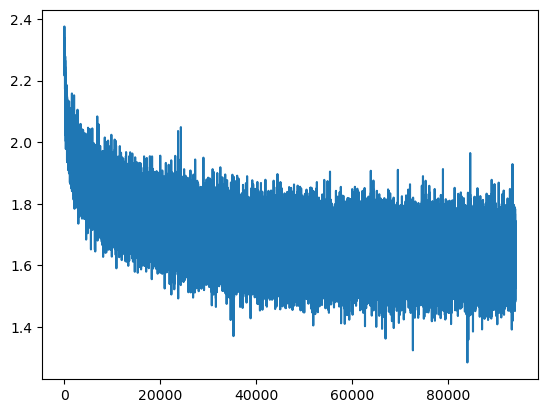

In [27]:
with open(log_file, "r") as f:
    all_loss = [float(line) for line in f]
plt.plot(all_loss)

### 2. 加载扩散模型 (Load diffusion model)

接下来我们需要一个**预训练的扩散模型**。

在这个例子中，我们使用在 [DDPM 教程](./02-ddpm-cn.ipynb) 中训练的**无条件扩散模型**。
因此，以下代码与 [DDPM 教程](./02-ddpm-cn.ipynb) 中的相同。

如果您没有预训练的检查点（```ddpm_unet_499.pt```），您也可以直接使用 ```./model/ddpm_unit_499.pt```。

In [29]:
##########
# Copy from DDPM tutorial (see 02-ddpm.ipynb)
##########
class PositionalEncoding(nn.Module):
    def __init__(
        self,
        base_dim, # 128
        hidden_dim, # 256
        output_dim, # 512
    ):
        super().__init__()

        # In this example, we assume that the number of embedding dimension is always even.
        # (If not, please pad the result.)
        assert(base_dim % 2 == 0)
        self.timestep_dim = base_dim

        self.hidden1 = nn.Linear(
            base_dim,
            hidden_dim)
        self.hidden2 = nn.Linear(
            hidden_dim,
            output_dim)

    def forward(self, picked_up_timesteps):
        """
        Generate timestep embedding vectors
    
        Parameters
        ----------
        picked_up_timesteps : torch.tensor((batch_size), dtype=int)
            Randomly picked up timesteps
    
        Returns
        ----------
        out : torch.tensor((batch_size, output_dim), dtype=float)
            Generated timestep embeddings (vectors) for each timesteps.
        """

        # Generate 1 / 10000^{2i / d_e}
        # shape : (timestep_dim / 2, )
        interval = 1.0 / (10000**(torch.arange(0, self.timestep_dim, 2.0).to(device) / self.timestep_dim))
        # Generate t / 10000^{2i / d_e}
        # shape : (batch_size, timestep_dim / 2)
        position = picked_up_timesteps.type(torch.get_default_dtype())
        radian = position[:, None] * interval[None, :]
        # Get sin(t / 10000^{2i / d_e}) and unsqueeze
        # shape : (batch_size, timestep_dim / 2, 1)
        sin = torch.sin(radian).unsqueeze(dim=-1)
        # Get cos(t / 10000^{2i / d_e}) and unsqueeze
        # shape : (batch_size, timestep_dim / 2, 1)
        cos = torch.cos(radian).unsqueeze(dim=-1)
        # Get sinusoidal positional encoding
        # shape : (batch_size, timestep_dim)
        pe_tmp = torch.concat((sin, cos), dim=-1)   # shape : (num_timestep, timestep_dim / 2, 2)
        d = pe_tmp.size()[1]
        pe = pe_tmp.view(-1, d * 2)                 # shape : (num_timestep, timestep_dim)
        # Apply feedforward
        # shape : (batch_size, timestep_dim * 4)
        out = self.hidden1(pe)
        out = F.silu(out)
        out = self.hidden2(out)

        return out

In [30]:
##########
# Copy from DDPM tutorial (see 02-ddpm.ipynb)
##########
class ResnetBlock(nn.Module):
    def __init__(
        self,
        in_channel,
        out_channel,
        num_norm_groups, # 32
        timestep_embedding_dim, # 512
    ):
        super().__init__()

        # for normalization
        self.norm1 = nn.GroupNorm(
            num_groups=num_norm_groups,
            num_channels=in_channel,
            eps=1e-06,
        )
        self.norm2 = nn.GroupNorm(
            num_groups=num_norm_groups,
            num_channels=out_channel,
            eps=1e-06,
        )

        # for applying conv
        self.conv1 = nn.Conv2d(
            in_channel,
            out_channel,
            kernel_size=3,
            stride=1,
            padding="same",
        )
        self.conv2 = nn.Conv2d(
            out_channel,
            out_channel,
            kernel_size=3,
            stride=1,
            padding="same",
        )

        # for adding timestep
        self.linear_pos = nn.Linear(timestep_embedding_dim, out_channel)

        # for residual block
        if in_channel != out_channel:
            self.linear_src = nn.Linear(in_channel, out_channel)
        else:
            self.linear_src = None

    def forward(self, x, t_emb):
        """
        Parameters
        ----------
        x : torch.tensor((batch_size, in_channel, width, height), dtype=float)
            input x
        t_emb : torch.tensor((batch_size, base_channel_dim * 4), dtype=float)
            timestep embeddings
        """

        # Apply conv
        out = self.norm1(x)
        out = F.silu(out)
        out = self.conv1(out)

        # Add timestep encoding
        pos = F.silu(t_emb)
        pos = self.linear_pos(pos)
        pos = pos[:, :, None, None]
        out = out + pos

        # apply dropout + conv
        out = self.norm2(out)
        out = F.silu(out)
        out = F.dropout(out, p=0.1, training=self.training)
        out = self.conv2(out)

        # apply residual
        if self.linear_src is not None:
            x_trans = x.permute(0, 2, 3, 1)       # (N,C,H,W) --> (N,H,W,C)
            x_trans = self.linear_src(x_trans)
            x_trans = x_trans.permute(0, 3, 1, 2) # (N,H,W,C) --> (N,C,H,W)
            out = out + x_trans
        else:
            out = out + x

        return out

#
# For the implementation of multi-head attention,
# see https://github.com/tsmatz/nlp-tutorials/blob/master/09_transformer.ipynb
#
class AttentionBlock(nn.Module):
    def __init__(
        self,
        channel,
        num_norm_groups, # 32
    ):
        super().__init__()

        self.norm = nn.GroupNorm(
            num_groups=num_norm_groups,
            num_channels=channel,
            eps=1e-06,
        )

        self.q_layer = nn.Linear(channel, channel)
        self.k_layer = nn.Linear(channel, channel)
        self.v_layer = nn.Linear(channel, channel)

        self.output_linear = nn.Linear(channel, channel, bias=False)

    def forward(self, x):
        channel = x.size(dim=1)
        height = x.size(dim=2)
        width = x.size(dim=3)

        out = self.norm(x)

        # reshape : (N,C,H,W) --> (N,H*W,C)
        out = out.permute(0, 2, 3, 1)
        out = out.view(-1, height*width, channel)

        # generate query/key/value
        q = self.q_layer(out)
        k = self.k_layer(out)
        v = self.v_layer(out)

        # compute Q K^T
        score = torch.einsum("bic,bjc->bij", q, k)

        # scale the result by 1/sqrt(channel)
        score = score / channel**0.5

        # apply softtmax
        score = F.softmax(score, dim=-1)

        # apply dot product with values
        out = torch.einsum("bij,bjc->bic", score, v)

        # apply final linear
        out = self.output_linear(out)

        # reshape : (N,H*W,C) --> (N,C,H,W)
        out = out.view(-1, height, width, channel)
        out = out.permute(0, 3, 1, 2)

        # apply residual
        out = out + x

        return out

class ResnetAndAttention(nn.Module):
    def __init__(
        self,
        in_channel,
        out_channel,
        num_norm_groups, # 32
        timestep_embedding_dim, # 512
    ):
        super().__init__()

        self.resnet = ResnetBlock(
            in_channel,
            out_channel,
            num_norm_groups,
            timestep_embedding_dim,
        )
        self.attention = AttentionBlock(
            out_channel,
            num_norm_groups,
        )

    def forward(self, x, t_emb):
        """
        Parameters
        ----------
        x : torch.tensor((batch_size, in_channel, width, height), dtype=float)
            input x
        t_emb : torch.tensor((batch_size, base_channel_dim * 4), dtype=float)
            timestep embeddings
        """
        out = self.resnet(x, t_emb)
        out = self.attention(out)
        return out

# Resized into the shape (C,H/2,W/2)
# (This is equivalent to torch.nn.Conv2d.)
class DownSample(nn.Module):
    def __init__(
        self,
        channel,
    ):
        super().__init__()

        self.conv = nn.Conv2d(
            channel,
            channel,
            kernel_size=3,
            stride=2,
            padding=1,
        )

    def forward(self, x):
        return self.conv(x)

# Resized into the shape (C,H*2,W*2)
class UpSample(nn.Module):
    def __init__(
        self,
        channel,
    ):
        super().__init__()

        self.conv = nn.Conv2d(
            channel,
            channel,
            kernel_size=3,
            stride=1,
            padding="same",
        )

    def forward(self, x):
        out = F.interpolate(x, scale_factor=2, mode="nearest")
        out = self.conv(out)
        return out

In [31]:
##########
# Copy from DDPM tutorial (see 02-ddpm.ipynb)
##########
class UNet(nn.Module):
    def __init__(
        self,
        source_channel, # 3
        unet_base_channel, # 128
        num_norm_groups, # 32
    ):
        super().__init__()

        self.pos_enc = PositionalEncoding(
            base_dim=unet_base_channel,
            hidden_dim=unet_base_channel*2,
            output_dim=unet_base_channel*4,
        )

        self.down_conv = nn.Conv2d(
            source_channel,
            unet_base_channel,
            kernel_size=3,
            stride=1,
            padding="same",
        )
        self.top_to_down = nn.ModuleList([
            # 1st layer
            ResnetBlock(
                in_channel=unet_base_channel,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            DownSample(
                channel=unet_base_channel,
            ),
            # 2nd layer
            ResnetAndAttention(
                in_channel=unet_base_channel,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            ResnetAndAttention(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            DownSample(
                channel=unet_base_channel*2,
            ),
            # 3rd layer
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            DownSample(
                channel=unet_base_channel*2,
            ),
            # 4th layer
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
        ])
        self.middle = nn.ModuleList([
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            AttentionBlock(
                channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
        ])
        self.bottom_to_up = nn.ModuleList([
            # 1st layer
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            UpSample(
                channel=unet_base_channel*2,
            ),
            # 2nd layer
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            UpSample(
                channel=unet_base_channel*2,
            ),
            # 3rd layer
            ResnetAndAttention(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            ResnetAndAttention(
                in_channel=unet_base_channel*4,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            ResnetAndAttention(
                in_channel=unet_base_channel*3,
                out_channel=unet_base_channel*2,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            UpSample(
                channel=unet_base_channel*2,
            ),
            # 4th layer
            ResnetBlock(
                in_channel=unet_base_channel*3,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
            ResnetBlock(
                in_channel=unet_base_channel*2,
                out_channel=unet_base_channel,
                num_norm_groups=num_norm_groups,
                timestep_embedding_dim=unet_base_channel*4,
            ),
        ])
        self.norm = nn.GroupNorm(
            num_groups=num_norm_groups,
            num_channels=unet_base_channel,
            eps=1e-06,
        )
        self.up_conv = nn.Conv2d(
            unet_base_channel,
            source_channel,
            kernel_size=3,
            stride=1,
            padding="same",
        )

    def forward(self, x, t):
        """
        Parameters
        ----------
        x : torch.tensor((batch_size, in_channel, width, height), dtype=float)
            Gaussian-noised images
        t : torch.tensor((batch_size), dtype=int)
            timestep
        """

        buffer = []

        # generate time embedding
        time_embs = self.pos_enc(t)

        #
        # Top-to-down
        #

        # apply down-convolution
        out = self.down_conv(x)
        buffer.append(out)
        # apply top-to-down
        for block in self.top_to_down:
            if isinstance(block, ResnetBlock):
                out = block(out, time_embs)
            elif isinstance(block, ResnetAndAttention):
                out = block(out, time_embs)
            elif isinstance(block, DownSample):
                out = block(out)
            else:
                raise Exception("Unknown block")
            buffer.append(out)

        #
        # Middle
        #
        for block in self.middle:
            if isinstance(block, ResnetBlock):
                out = block(out, time_embs)
            elif isinstance(block, AttentionBlock):
                out = block(out)
            else:
                raise Exception("Unknown block")

        #
        # Bottom-to-up
        #

        # apply bottom-to-up
        for block in self.bottom_to_up:
            if isinstance(block, ResnetBlock):
                buf = buffer.pop()
                out = torch.cat((out, buf), dim=1)
                out = block(out, time_embs)
            elif isinstance(block, ResnetAndAttention):
                buf = buffer.pop()
                out = torch.cat((out, buf), dim=1)
                out = block(out, time_embs)
            elif isinstance(block, UpSample):
                out = block(out)
            else:
                raise Exception("Unknown block")
        # apply up-convolution
        out = self.norm(out)
        out = F.silu(out)
        out = self.up_conv(out)

        assert not buffer

        return out

In [53]:
#
# Load a pretrained model
#
unet = UNet(
    source_channel=3,
    unet_base_channel=128,
    num_norm_groups=32,
).to(device)
unet.load_state_dict(torch.load("./model/ddpm_unet_499.pt", weights_only=True))

<All keys matched successfully>

### 3. 使用分类器引导生成图像

现在我们开始在采样（生成）过程中应用分类器引导来生成图像。

如前文所述，采样算法如下：

1. 采样初始白噪声

   $
   \mathbf{x}_T \sim \mathcal{N}(\mathbf{0}, \mathbf{I})
   $

3. 对 $t = T, \ldots, 1$，循环执行以下步骤：

   - 计算均值

     $
     \mu \leftarrow \mu_{\theta}(\mathbf{x}_t, t),
     $
     其中
     
     $
     \mu_{\theta}(\mathbf{x}_t, t)
     = \frac{1}{\sqrt{\alpha_t}}
     \left(
     \mathbf{x}_t - \frac{1 - \alpha_t}{\sqrt{1 - \overline{\alpha}_t}}
     \epsilon_{\theta}(\mathbf{x}_t, t)
     \right)
     $

   - 采样

     $
     \mathbf{x}_{t-1}
     \sim
     \mathcal{N}
     \big(
     \mu + s \sigma_t^2 \nabla_{\mathbf{x}_t} \log p_{\phi}(y \mid \mathbf{x}_t),
     \;
     \sigma_t^2 \mathbf{I}
     \big),
     $

     其中
     $
     \sigma_t^2 = \frac{(1 - \alpha_t)(1 - \overline{\alpha}_{t-1})}{1 - \overline{\alpha}_t},
     $
     且 $s$ 为梯度缩放系数（固定超参数）。

4. 返回最终生成结果 $\mathbf{x}_0$

> 注：在带有扩散引导的图像生成（采样）过程中，也可以使用 DDIM（Denoising Diffusion Implicit Models）来加速推理过程。  
> 具体实现可参见 [官方代码仓库](https://github.com/openai/guided-diffusion)。


In [56]:
import tqdm

def run_inference(unet, classifier, class_name, class_list, gradient_scale, num_row=10, num_col=10):
    unet.eval()
    classifier.eval()

    #####
    # preparation
    #####

    # generate array of sigma_t
    alpha_bars_prev = torch.cat((torch.ones(1).to(device), alpha_bars[:-1]))
    sigma_t_squared = (1.0 - alphas) * (1.0 - alpha_bars_prev) / (1.0 - alpha_bars)
    sigma_t = torch.sqrt(sigma_t_squared)

    # generate y (tensor batch array of class id)
    class_id_list = [i for i,v in enumerate(class_list) if v==class_name]
    if len(class_id_list) == 0:
        raise Exception("class name doesn't exist")
    y = class_id_list[0]
    y_batch = (torch.tensor(y).to(device)).repeat(num_row*num_col)

    #####
    # 1. make white noise
    #####
    x = torch.randn(num_row*num_col, 3, 32, 32).to(device)

    #####
    # 2. loop
    #####
    for t in tqdm.tqdm(reversed(range(T)), total=T):
        # get mu
        t_batch = (torch.tensor(t).to(device)).repeat(num_row*num_col)
        with torch.no_grad():
            epsilon = unet(x, t_batch)
        mu = (1.0 / torch.sqrt(alphas[t])).float() * (x - ((1.0 - alphas[t]) / torch.sqrt(1.0 - alpha_bars[t])).float() * epsilon)

        # get nabla_x(log(p(y|x))) at x_t
        x_in = x.detach().requires_grad_(True)
        logits = classifier(x_in, t_batch)
        log_probs = F.log_softmax(logits, dim=-1)
        selected = log_probs[range(len(logits)), y_batch.view(-1)]
        grad = torch.autograd.grad(selected.sum(), x_in)[0]

        # pick up x_{t-1}
        if t > 0:
            z = torch.randn_like(x).to(device)
        else:
            z = torch.zeros_like(x).to(device)
        x = mu + gradient_scale * sigma_t_squared[t].float() * grad + \
            sigma_t[t].float() * z

    #####
    # 3. get x_0
    #####

    # reshape to channels-last : (N,C,H,W) --> (N,H,W,C)
    x = x.permute(0, 2, 3, 1)
    # clip
    x = torch.clamp(x, min=0.0, max=1.0)

    #####
    # draw
    #####
    fig, axes = plt.subplots(num_row, num_col, figsize=(5,5))
    for i in range(num_row*num_col):
        image = x[i].cpu().numpy()
        row = i//num_col
        col = i%num_col
        ax = axes[row, col]
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(image)

100%|██████████| 1000/1000 [01:57<00:00,  8.50it/s]


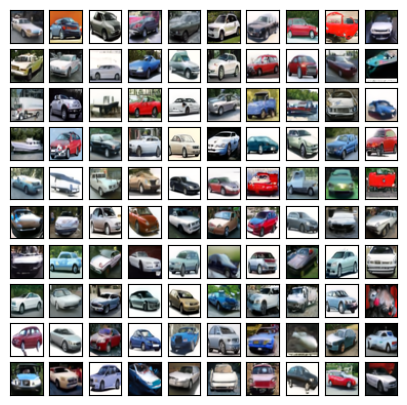

In [58]:
run_inference(
    unet,
    classifier,
    "automobile",
    class_list=classes,
    gradient_scale=10.0
)

100%|██████████| 1000/1000 [01:57<00:00,  8.48it/s]


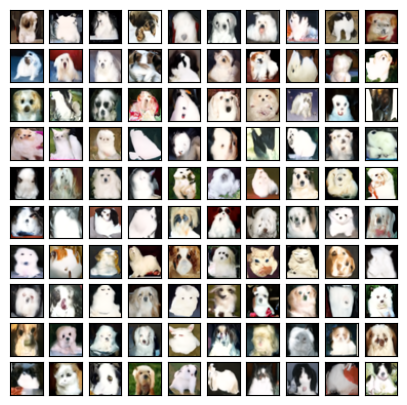

In [59]:
run_inference(
    unet,
    classifier,
    "dog",
    class_list=classes,
    gradient_scale=10.0
)

100%|██████████| 1000/1000 [01:57<00:00,  8.48it/s]


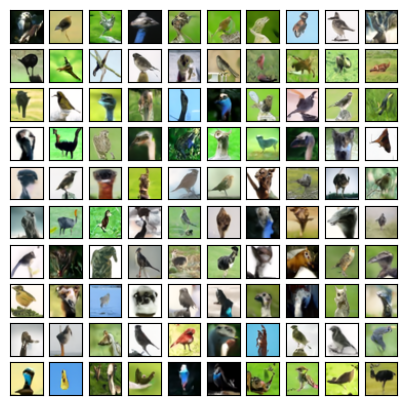

In [64]:
run_inference(
    unet,
    classifier,
    "bird",
    class_list=classes,
    gradient_scale=10.0
)